1 — IMPORTS

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")


2 — Load the CSV Files

In [2]:
products = pd.read_csv("products_dataset.csv")
sales = pd.read_csv("sales_dataset.csv")
inventory = pd.read_csv("inventory_dataset.csv")

products.head(), sales.head(), inventory.head()


(   ProductID     Category       SubCategory           ProductName  CostPrice  \
 0       1001         Toys  Educational Toys  Funskool Educational    2410.85   
 1       1002         Toys             Games            Lego Games     101.78   
 2       1003  Electronics     Audio Devices          Xiaomi Audio    4750.60   
 3       1004       Beauty          Skincare         Olay Skincare     978.48   
 4       1005         Toys             Games    Chhota Bheem Games    2610.42   
 
    SupplierID  
 0          73  
 1          76  
 2          31  
 3          52  
 4          21  ,
    OrderID   OrderDate  ProductID  Quantity  UnitPrice  Discount Region
 0    80000  2023-09-09       1299         1    4899.52      0.05  South
 1    80001  2023-09-24       1166         3    5384.51      0.15  North
 2    80002  2023-06-22       1102         1    6996.15      0.10   East
 3    80003  2023-03-05       1494         1    8668.14      0.20  South
 4    80004  2023-11-26       1016         5

3 — MERGE SALES + PRODUCTS

In [3]:
df = sales.merge(products, on="ProductID")
df.head()


,OrderID,OrderDate,ProductID,Quantity,UnitPrice,Discount,Region,Category,SubCategory,ProductName,CostPrice,SupplierID
0,80000,2023-09-09,1299,1,4899.52,0.05,South,Clothing,Ethnic Wear,Roadster Ethnic,2863.21,63
1,80001,2023-09-24,1166,3,5384.51,0.15,North,Beauty,Cosmetics,Nykaa Cosmetics,3473.88,67
2,80002,2023-06-22,1102,1,6996.15,0.10,East,Grocery,Household Essentials,MTR Household,4531.50,2
3,80003,2023-03-05,1494,1,8668.14,0.20,South,Toys,Games,Hot Wheels Games,4425.47,51
4,80004,2023-11-26,1016,5,438.22,0.20,East,Sports,Fitness,Cosco Fitness,436.82,7


4 — CREATE REVENUE, COST & PROFIT

In [4]:
df["Revenue"] = df["UnitPrice"] * df["Quantity"]
df["Cost"] = df["CostPrice"] * df["Quantity"]
df["Profit"] = df["Revenue"] - df["Cost"]


5 — EXTRACT MONTH

In [5]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["Month"] = df["OrderDate"].dt.strftime("%b")


6 — CATEGORY & SUBCATEGORY PROFIT

Category Profit

In [6]:
category_profit = df.groupby("Category")[["Revenue","Cost","Profit"]].sum().reset_index()
category_profit


,Category,Revenue,Cost,Profit
0,Beauty,15737735.49,8764763.97,6972971.52
1,Clothing,18620585.21,10228100.63,8392484.58
2,Electronics,16097242.44,8932882.67,7164359.77
3,Grocery,12576317.76,7061866.49,5514451.27
4,Home & Kitchen,15233899.57,8466497.32,6767402.25
5,Sports,13749282.09,7672050.55,6077231.54
6,Toys,14804241.66,8355671.42,6448570.24


Subcategory Profit

In [7]:
subcategory_profit = df.groupby(["Category","SubCategory"])[["Revenue","Cost","Profit"]].sum().reset_index()
subcategory_profit


,Category,SubCategory,Revenue,Cost,Profit
0,Beauty,Cosmetics,5161479.61,2827692.27,2333787.34
1,Beauty,Haircare,4689612.05,2657916.08,2031695.97
2,Beauty,Skincare,5886643.83,3279155.62,2607488.21
3,Clothing,Ethnic Wear,5833661.71,3236395.39,2597266.32
4,Clothing,Jackets,4911758.75,2671481.96,2240276.79
5,Clothing,Jeans,4280779.61,2336292.24,1944487.37
6,Clothing,Shirts,3594385.14,1983931.04,1610454.10
7,Electronics,Audio Devices,3892910.92,2192779.92,1700131.00
8,Electronics,Cameras,1827128.72,1017653.20,809475.52
9,Electronics,Laptops,2647734.29,1472436.32,1175297.97


7 — MONTHLY REVENUE

In [14]:

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reindex(month_order) 
      .reset_index()
)

monthly_revenue



,Month,Revenue
0,Jan,9505835.73
1,Feb,8048027.98
2,Mar,9063281.53
3,Apr,8489862.62
4,May,8522516.24
5,Jun,8940535.19
6,Jul,8600001.60
7,Aug,8804171.40
8,Sep,9208064.43
9,Oct,9225195.78


8 — INVENTORY USAGE + PROFIT MERGE

In [9]:
inventory["UsedStock"] = inventory["OpeningStock"] - inventory["ClosingStock"]
inv_used = inventory.groupby("ProductID")["UsedStock"].sum().reset_index()

profit_per_product = df.groupby("ProductID")["Profit"].sum().reset_index()

inv_merge = inv_used.merge(profit_per_product, on="ProductID")
inv_merge.head()


,ProductID,UsedStock,Profit
0,1001,1047,106076.45
1,1002,1046,3342.61
2,1003,664,161859.06
3,1004,748,31511.02
4,1005,1061,62791.63


9 — CORRELATION

In [10]:
inv_merge.corr()


,ProductID,UsedStock,Profit
ProductID,1.000000,0.008276,0.031958
UsedStock,0.008276,1.000000,-0.007686
Profit,0.031958,-0.007686,1.000000


10 — ALL VISUALS (Seaborn)

1 — Category-wise Profit

C:\Users\BHARATH\AppData\Local\Temp\ipykernel_3888\1934173279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit, x="Category", y="Profit", palette="viridis")


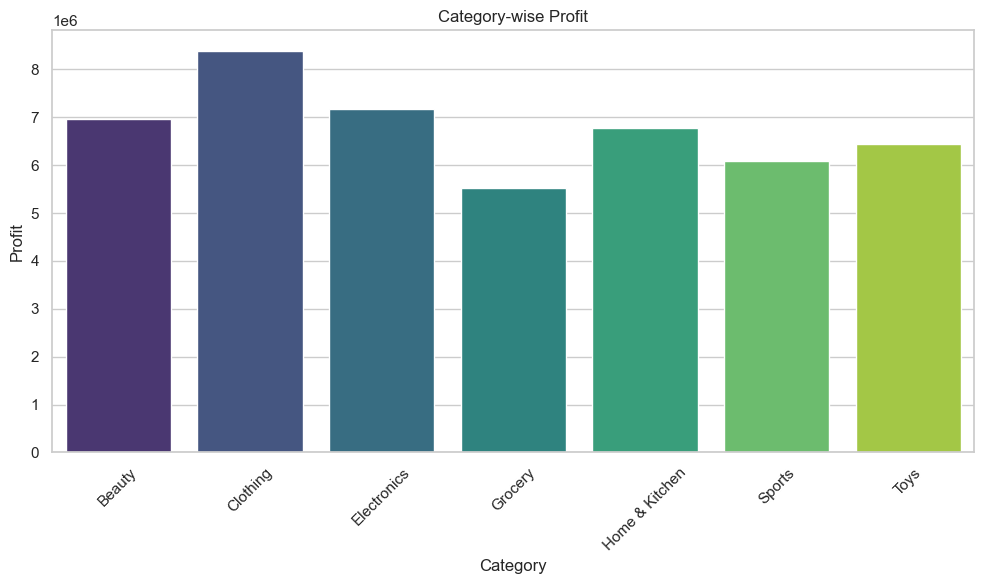

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_profit, x="Category", y="Profit", palette="viridis")
plt.xticks(rotation=45)
plt.title("Category-wise Profit")
plt.tight_layout()
plt.show()


2 — Subcategory-wise Profit

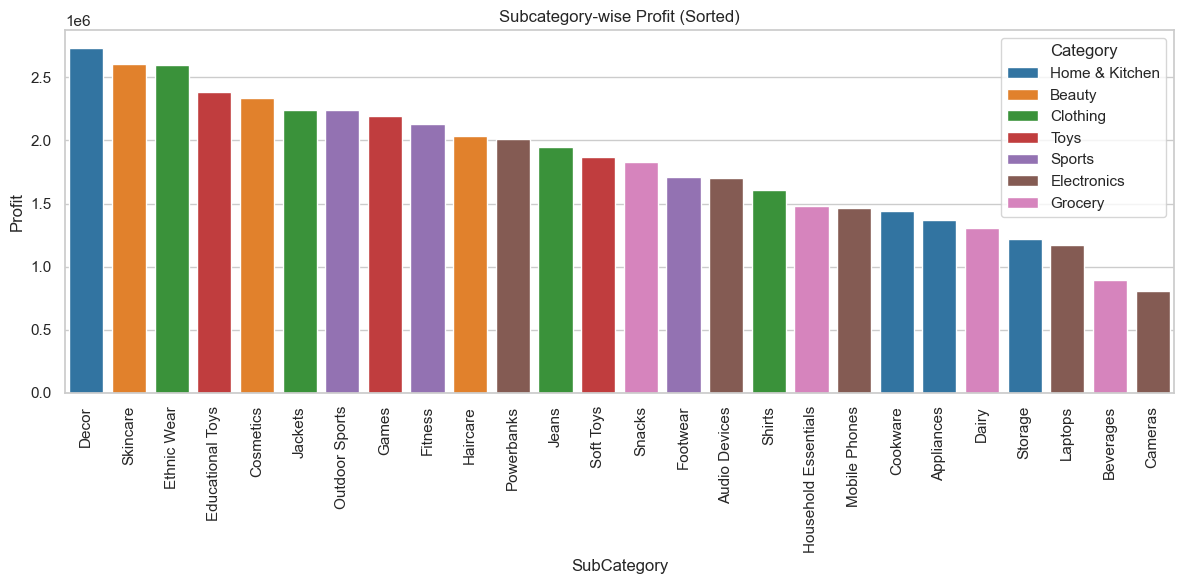

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=subcategory_profit.sort_values("Profit", ascending=False),
    x="SubCategory", y="Profit", hue="Category", dodge=False, palette="tab10"
)
plt.xticks(rotation=90)
plt.title("Subcategory-wise Profit (Sorted)")
plt.tight_layout()
plt.show()



3 — Monthly Revenue Trend (Jan → Dec)

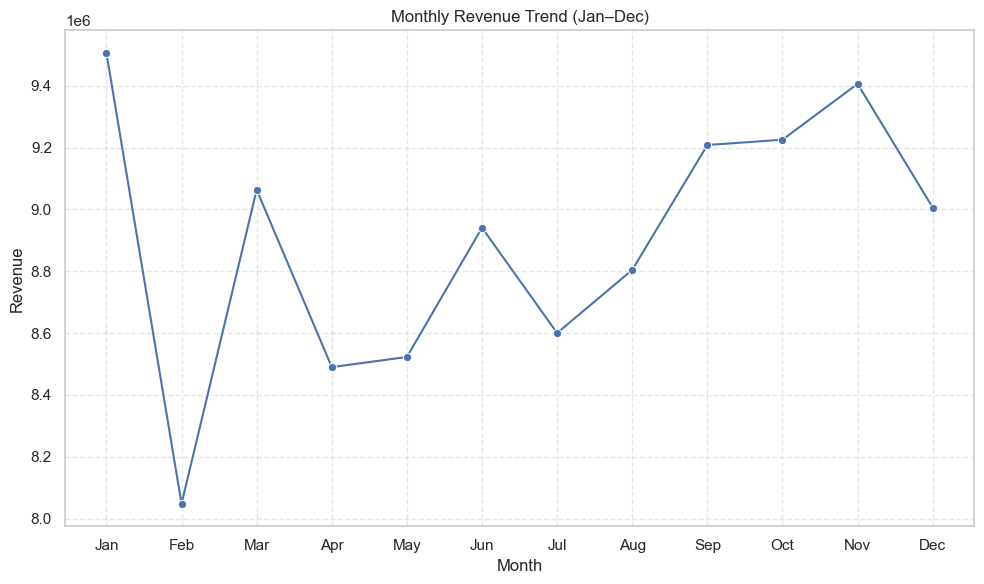

In [24]:
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_revenue, x="Month", y="Revenue", marker="o")
plt.title("Monthly Revenue Trend (Jan–Dec)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


4 — Inventory Used vs Profit

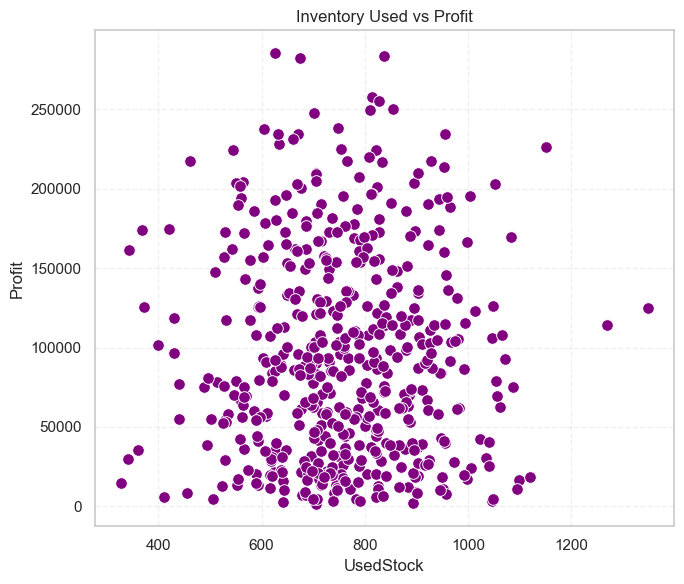

In [25]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=inv_merge, x="UsedStock", y="Profit", s=70, color="purple")
plt.title("Inventory Used vs Profit")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


5 — Correlation Heatmap

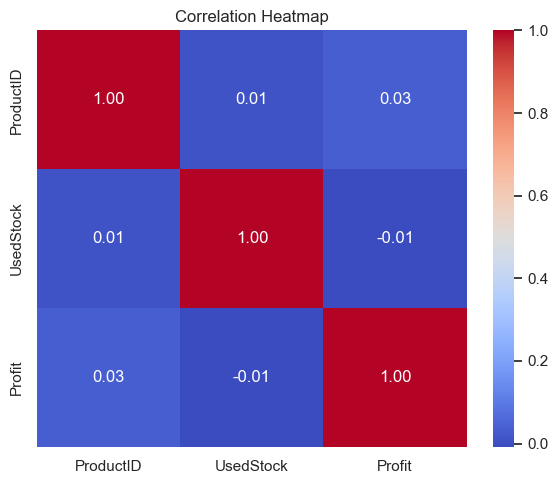

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(inv_merge.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


6 — Top 10 Products by Revenue

C:\Users\BHARATH\AppData\Local\Temp\ipykernel_3888\915310522.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="ProductID", y="Revenue", palette="magma")


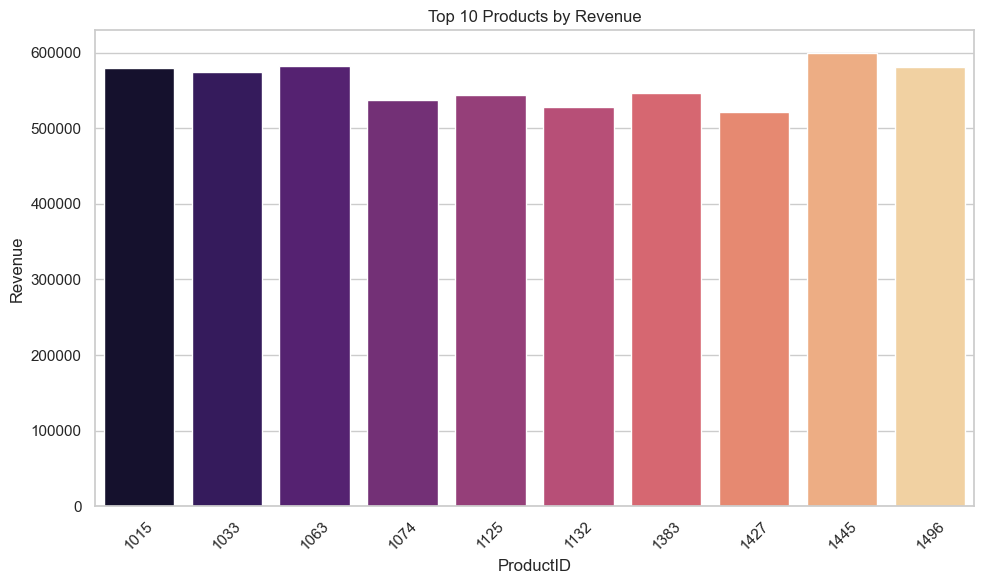

In [27]:
top10 = df.groupby("ProductID")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="ProductID", y="Revenue", palette="magma")
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


7 — Profit by Region

C:\Users\BHARATH\AppData\Local\Temp\ipykernel_3888\1527443422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x="Region", y="Profit", palette="cubehelix")


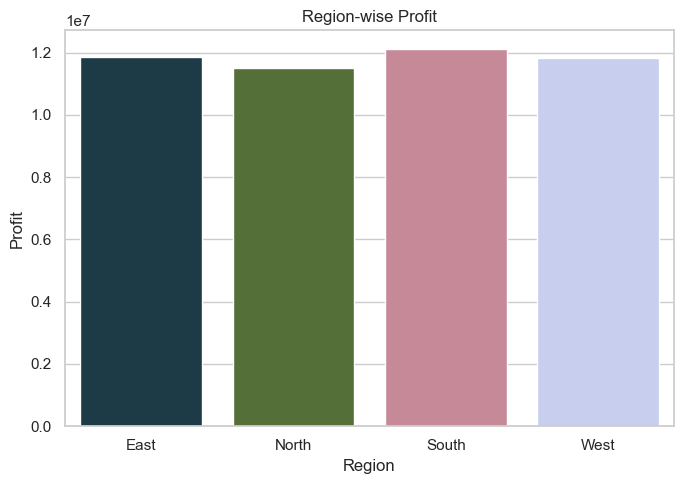

In [28]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=region_profit, x="Region", y="Profit", palette="cubehelix")
plt.title("Region-wise Profit")
plt.tight_layout()
plt.show()
